<a href="https://colab.research.google.com/github/moist234/ECON3916-Statistical-Machine-Learning/blob/main/Assignment4/Econ_3916_Assignment_4_PredictiveArchitecture.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [54]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.eval_measures import rmse
import missingno as msno
import category_encoders as ce
import seaborn as sns
import matplotlib.pyplot as plt

In [55]:
vitals_df = pd.read_csv('https://raw.githubusercontent.com/moist234/ECON3916-Statistical-Machine-Learning/refs/heads/main/Data/OmniCare_Clinical_Vitals.csv')
telemetry_df = pd.read_csv('https://raw.githubusercontent.com/moist234/ECON3916-Statistical-Machine-Learning/refs/heads/main/Data/OmniCare_Telemetry_Data.csv')

In [56]:
# Phase 1
# Step 1.1
# Omitted Confounder is Wealth / Socioeconomic Status
#
# Fork DAG:
#   Wealth: High_Deductible_Insurance_Plan
#   Wealth: Inpatient_Admission_Rate
#
# Wealthier patients can afford low-deductible plans and also tend to be
# healthier due to better nutrition, less stress, and more access to
# preventative care. Without wealth in the regression, OLS cannot separate
# the effect of insurance type from the effect of wealth. The coefficient
# on Insurance_Type picks up both effects at once, making it wrong.
# This happens because the regressor is correlated with the error term,
# which violates the  assumption E[e|X] = 0.

In [57]:
# Step 1.2
features = ['Weight_kg', 'Height_cm', 'BMI', 'Systolic_BP', 'Diastolic_BP']
X_vif = sm.add_constant(vitals_df[features].dropna())
exog_matrix = X_vif.values

print("\n--- VARIANCE INFLATION FACTORS ---")
for i in range(1, exog_matrix.shape[1]):
    vif = variance_inflation_factor(exog_matrix, i)
    print(f"{features[i-1]}: {vif:.2f}")

print("\nFeatures exceeding VIF threshold of 10.0:")
for i in range(1, exog_matrix.shape[1]):
    vif = variance_inflation_factor(exog_matrix, i)
    if vif > 10.0:
        print(f"{features[i-1]}: {vif:.2f}")


--- VARIANCE INFLATION FACTORS ---
Weight_kg: 57.43
Height_cm: 28.42
BMI: 16.98
Systolic_BP: 4.22
Diastolic_BP: 4.22

Features exceeding VIF threshold of 10.0:
Weight_kg: 57.43
Height_cm: 28.42
BMI: 16.98


In [58]:
features_reduced = ['Weight_kg', 'Height_cm', 'Systolic_BP', 'Diastolic_BP']
X_vif2 = sm.add_constant(vitals_df[features_reduced].dropna())
exog_matrix2 = X_vif2.values

print("\n--- POST-DROP VIF ---")
for i in range(1, exog_matrix2.shape[1]):
    vif = variance_inflation_factor(exog_matrix2, i)
    print(f"{features_reduced[i-1]}: {vif:.2f}")


--- POST-DROP VIF ---
Weight_kg: 3.76
Height_cm: 3.76
Systolic_BP: 4.22
Diastolic_BP: 4.22


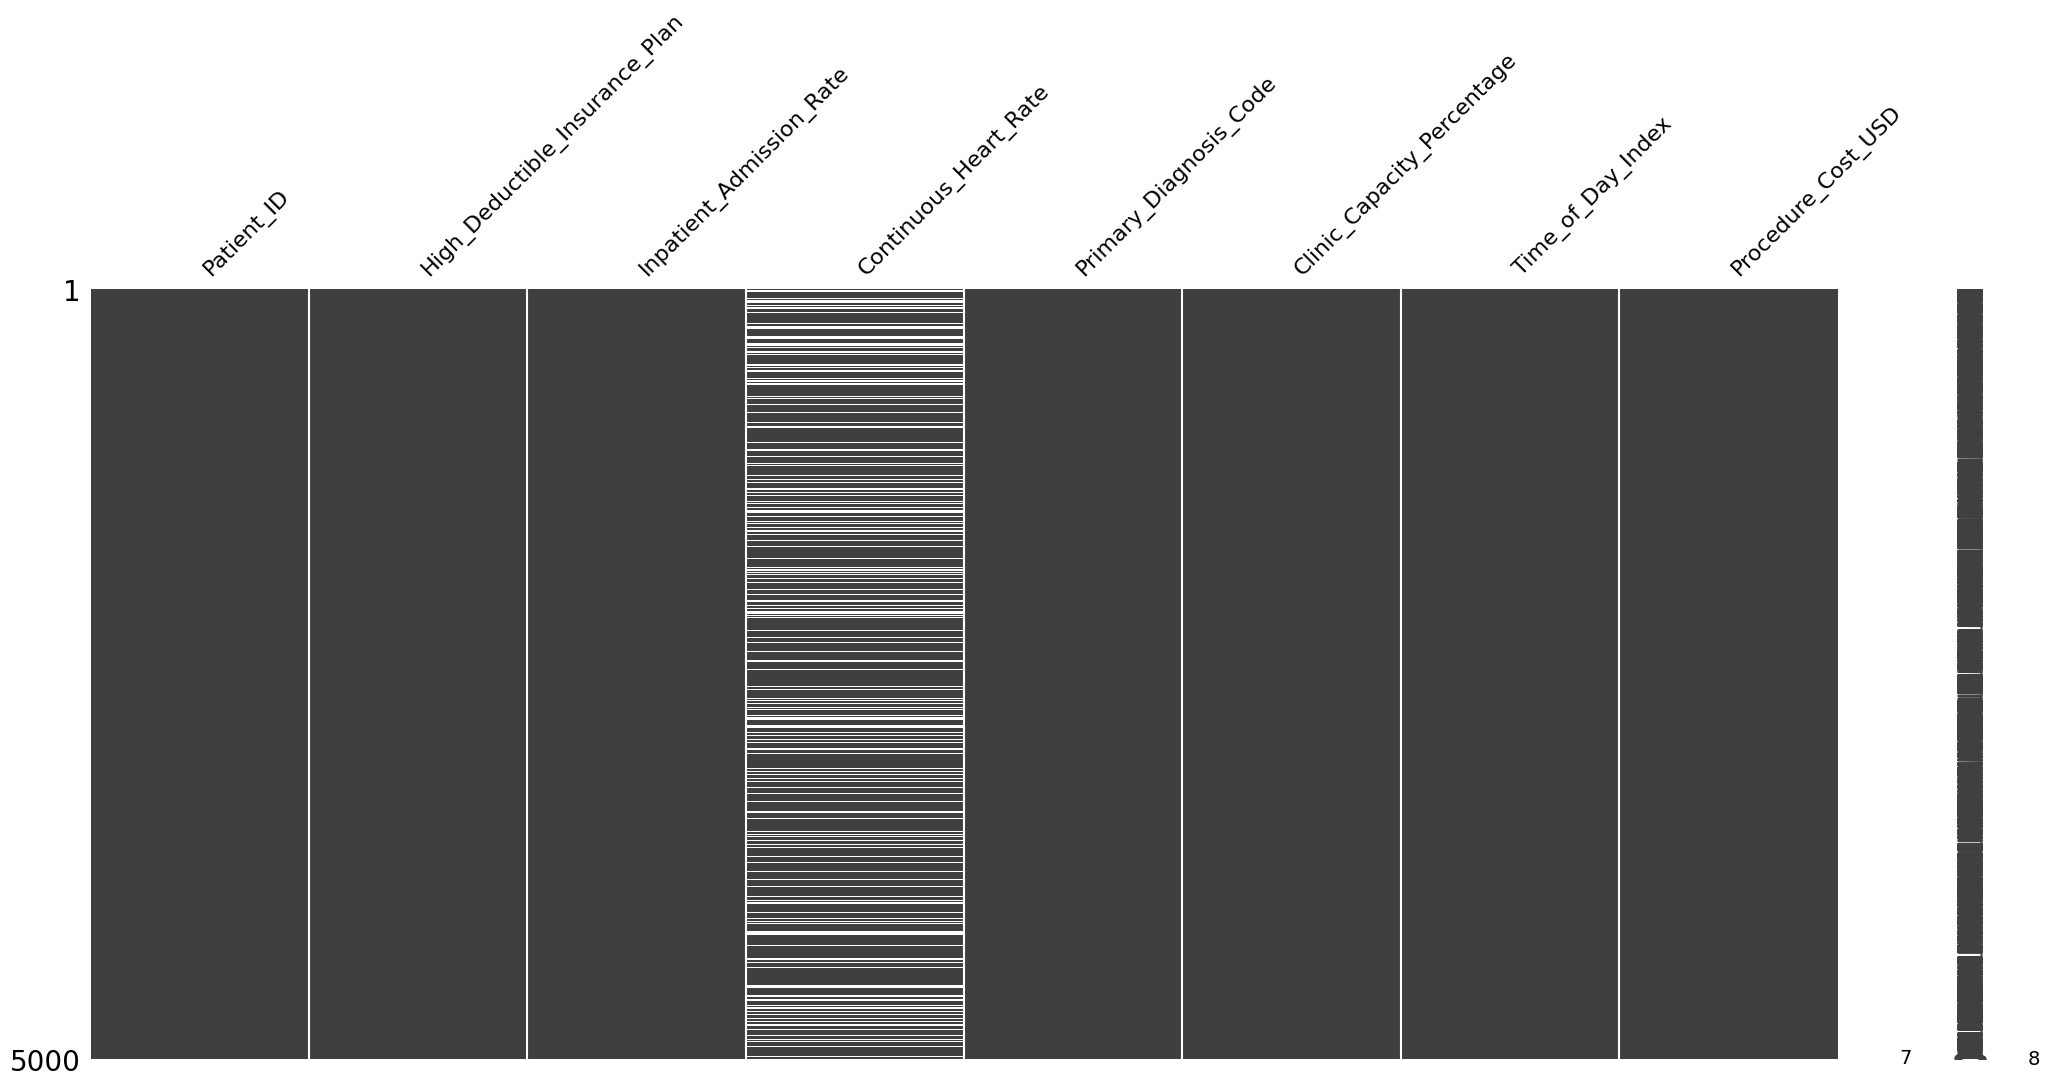

In [59]:
# Phase 2
# Step 2.1

msno.matrix(telemetry_df)
plt.show()

# This is MNAR
# The data is missing because low-income patients cannot afford the
# data plans required for continuous heart rate transmission. The
# chance of missing data is tied to patient income, which is also
# tied to health outcomes. Mean imputation would replace missing values
# with the average heart rate across all patients. This is wrong because
# the missing patients are not average. They are the sickest, lowes income
# group. Filling their data with the population mean hides their true risk.

In [60]:
# Step 2.2
# With 850 ICD-10 codes, pd.get_dummies() creates 850 binary columns.
# If you include all 850 columns plus an intercept, the 850 columns
# always add up to 1 for every row, which is the same as the intercept column.
# This means one column is a perfect copy of a combination of others.
# The design matrix X becomes singular: its inverse does not exist.
# OLS requires computing (X'X)^-1, so the estimator breaks down.
# The standard fix is to drop one dummy column. Target encoding avoids
# the problem by replacing all 850 columns with a single number.

In [61]:
# Step 2.3
encoder = ce.TargetEncoder(cols=['Primary_Diagnosis_Code'])
telemetry_df['Target_Encoded_Diagnosis'] = encoder.fit_transform(
    telemetry_df['Primary_Diagnosis_Code'],
    telemetry_df['Procedure_Cost_USD']
)

print(telemetry_df[['Primary_Diagnosis_Code', 'Target_Encoded_Diagnosis']].head(5))

  Primary_Diagnosis_Code  Target_Encoded_Diagnosis
0                J86.381               1707.697108
1                M29.789               1792.303198
2                E49.618               1730.334968
3                E66.244               1725.060944
4                J45.553               1801.821085


In [62]:
# Phase 3
# Step 3.1
final_df = pd.merge(vitals_df, telemetry_df, on='Patient_ID').dropna()

formula = ('Procedure_Cost_USD ~ Target_Encoded_Diagnosis + '
           'Clinic_Capacity_Percentage + Time_of_Day_Index + '
           'Weight_kg + Height_cm + Systolic_BP + Diastolic_BP')

model = smf.ols(formula=formula, data=final_df)
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:     Procedure_Cost_USD   R-squared:                       0.254
Model:                            OLS   Adj. R-squared:                  0.253
Method:                 Least Squares   F-statistic:                     183.9
Date:                Tue, 24 Mar 2026   Prob (F-statistic):          3.87e-235
Time:                        00:03:11   Log-Likelihood:                -27366.
No. Observations:                3786   AIC:                         5.475e+04
Df Residuals:                    3778   BIC:                         5.480e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

In [63]:
# Step 3.2

y_pred = results.predict(final_df)
model_rmse = rmse(final_df['Procedure_Cost_USD'], y_pred)
print(f"\nThe Predictive RMSE is: ${model_rmse:,.2f}")

# If the RMSE is 450 dollars on a 1,200 dollar procedure, the model is off by
# about 37% per prediction on average. This means the hospital will
# charge the wrong price on a large share of procedures. Overcharging
# patients creates legal and compliance risk. Undercharging means the
# hospital loses money. If the errors grow as the predicted cost grows
# (visible in the residual plot), then the most expensive procedures
# are also the least accurate, which is where the financial risk is highest.


The Predictive RMSE is: $333.34


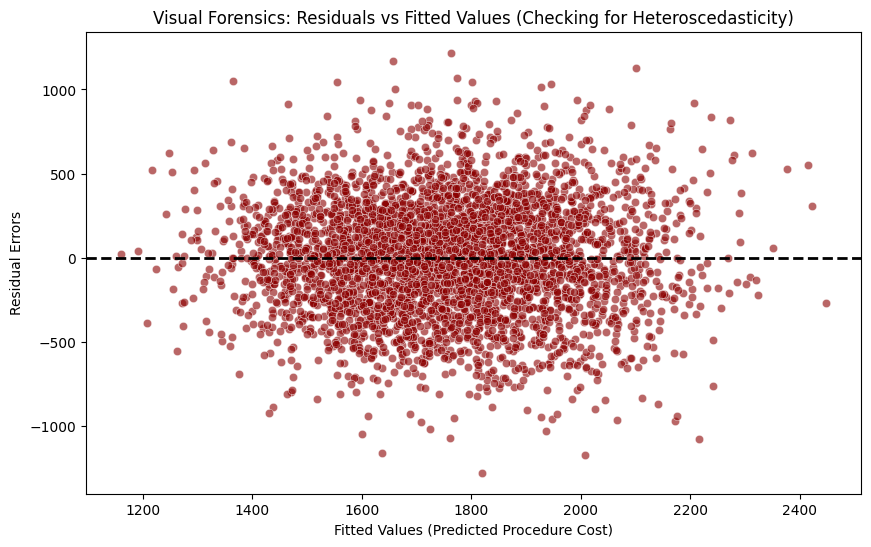

In [64]:
# Step 3.3

fitted_vals = results.fittedvalues
residuals   = results.resid

plt.figure(figsize=(10, 6))
sns.scatterplot(x=fitted_vals, y=residuals, alpha=0.6, color='darkred')
plt.axhline(0, color='black', linestyle='--', linewidth=2)
plt.title('Visual Forensics: Residuals vs Fitted Values (Checking for Heteroscedasticity)')
plt.xlabel('Fitted Values (Predicted Procedure Cost)')
plt.ylabel('Residual Errors')
plt.show()

# If the residuals fan out as fitted values increase, the model's errors
# grow as the predicted cost grows. This is heteroscedasticity.
# It means OLS standard errors are wrong, confidence intervals cannot
# be trusted, and t-statistics are not valid. The model is least reliable
# at high predicted costs, which is exactly where pricing errors are
# most expensive for the hospital and the patient.

In [65]:
# Phase 4
# Setp 4.1

# Persona: You are a professional econometrician who writes clean, minimal Python code.

# Role: You are assisting a student running OLS regression diagnostics in a Google Colab
# notebook using statsmodels.

# Instructions: Write a Python script that runs White's Lagrange Multiplier Test for
# heteroscedasticity on an existing OLS model called `results`, fitted using
# statsmodels.formula.api. Use the het_white function from
# statsmodels.stats.diagnostic. Extract the design matrix using results.model.exog.
# Print only the LM Statistic and the LM Test p-value. Use an f-string for the output.
# Add a single if/else statement that prints whether the null hypothesis of
# homoscedasticity is rejected at the 0.05 significance level.

# Meaning: The student needs to test whether the variance of residuals is constant
# across fitted values. A p-value below 0.05 means the OLS standard errors cannot
# be trusted and the model needs correction.

# Evaluation: The code must run without errors in Google Colab. It must use only
# statsmodels. Output must be clean and readable.

#output
from statsmodels.stats.diagnostic import het_white

exog_matrix = results.model.exog
residuals = results.resid

white_test = het_white(residuals, exog_matrix)

lm_stat   = white_test[0]
lm_pvalue = white_test[1]

print(f"LM Statistic: {lm_stat:.2f}")
print(f"LM Test p-value: {lm_pvalue:.4f}")

if lm_pvalue < 0.05:
    print("Conclusion: The null hypothesis of homoscedasticity is rejected. "
          "The model has heteroscedasticity and OLS standard errors are not valid.")
else:
    print("Conclusion: The null hypothesis of homoscedasticity is not rejected. "
          "The model errors have constant variance.")

LM Statistic: 159.21
LM Test p-value: 0.0000
Conclusion: The null hypothesis of homoscedasticity is rejected. The model has heteroscedasticity and OLS standard errors are not valid.
